# 02 — Diseño del preprocesado (antecesor)

> **Este notebook NO preprocesa: DECIDE y DEMUESTRA qué hará el preprocesado**, antes de escribirlo.
> Fija, con evidencia del EDA, *con qué features nos quedamos*, *cómo tratamos las frecuencias*, *cómo
> alineamos sin look-ahead* y *qué produce*. El siguiente notebook (`03_preprocesado`) solo implementa
> lo que aquí se decide.

Entradas: [`00_descarga.ipynb`](00_descarga.ipynb) (166 series), [`01_eda.ipynb`](01_eda.ipynb) (hallazgos),
[`../data/benchmark_spec.yaml`](../data/benchmark_spec.yaml) (ventanas + features congeladas).

**Decisiones marco (acordadas):** (1) **máximo de features** — núcleo del benchmark **+** un bloque
extendido; (2) **paneles separados por frecuencia** (diario / semanal / mensual), pensando cómo tratar
las no-diarias; (3) todo **causal** (z-score expanding, lag de publicación); (4) notebook **ejecutado**.

> **Conceptos** (pistas A/B, roles `spine/core/enricher/fallback/validation`, regla anti-fuga):
> [`docs/GLOSARIO.md`](../docs/GLOSARIO.md). `validation` = *ground truth*, **nunca** feature.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.3,'font.size':9,
                     'axes.spines.top':False,'axes.spines.right':False})
ROOT=Path.cwd()
while not (ROOT/'data'/'catalog.yaml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
sys.path.insert(0,str(ROOT)); import yaml
from src import features as ft
cov=pd.read_csv(ROOT/'data'/'raw'/'coverage_report.csv'); SRC=dict(zip(cov.nombre,cov.fuente))
ok=cov[cov.status.isin(['OK','CACHE'])].copy()
bench=yaml.safe_load((ROOT/'data'/'benchmark_spec.yaml').read_text(encoding='utf-8'))
def load(n): return pd.read_parquet(ROOT/'data'/'raw'/SRC[n]/f'{n}.parquet')[n].sort_index()
def tryload(n):
    try: return load(n)
    except Exception: return None
print('Series:',len(ok),'| benchmark: pista_A',bench['pista_A']['ventana_inicio'],'-> pista_B',bench['pista_B']['ventana_inicio'])

Series: 166 | benchmark: pista_A 1927-12-30 -> pista_B 2003-01-02


## 1. De qué partimos y qué debe producir el preprocesado

El pipeline es: **00 descarga → 01 EDA → 02 diseño (este) → 03 preprocesado → Fase D (detectores)**.
El preprocesado convierte las 166 series crudas (`data/raw/`, sin imputar) en **matrices de features
causales** listas para los detectores, congelando ventana y features por pista (`benchmark_spec.yaml`).
La regla de oro (heredada de la tarea previa): **nada de estadísticos de muestra completa** — toda
feature usa solo datos ≤ *t*.

## 2. Con qué features nos quedamos (máximo: núcleo + extendido)

Enumeramos **todas** las features candidatas por pista, marcando su **bloque** (`nucleo` = congelado en
`benchmark_spec`; `extendido` = añadido por su poder discriminante en el EDA), su **frecuencia**, la
**serie fuente** y la **transformación causal**.

In [2]:
FEAT = [
 # ---- PISTA A (espina profunda) ----
 ('A','SP500_ret_z','diaria','SP500','z(log-ret)','nucleo'),
 ('A','SP500_vol_z','diaria','SP500','z(realized_vol 21d)','nucleo'),
 ('A','SP500_momentum','diaria','SP500','momentum 12m-1m','nucleo'),
 ('A','SP500_drawdown','diaria','SP500','drawdown expanding','nucleo'),
 ('A','FF_MKT_z','diaria','FF_FACTORS_3_DAILY','z(Mkt-RF)','nucleo'),
 ('A','FF_MOM_z','diaria','FF_MOM_DAILY','z(momentum factor)','extendido'),
 ('A','credit_BaaAaa_z','mensual','MOODYS_BAA,MOODYS_AAA','z(Baa-Aaa)','nucleo'),
 ('A','INDPRO_yoy_z','mensual','INDPRO','z(YoY)','nucleo'),
 ('A','PPI_yoy_z','mensual','PPI_ALL_COMMODITIES','z(YoY)','nucleo'),
 ('A','UNRATE_chg_z','mensual','UNRATE','z(cambio 12m)','extendido'),
 # ---- PISTA B (panel rico) ----
 ('B','VIX_level_z','diaria','VIX','z(nivel)','nucleo'),
 ('B','VIX_change_z','diaria','VIX','z(cambio)','extendido'),
 ('B','MOVE_level_z','diaria','MOVE','z(nivel)','nucleo'),
 ('B','MOVE_change_z','diaria','MOVE','z(cambio) [velocidad tipos]','nucleo'),
 ('B','VVIX_z','diaria','VVIX','z(nivel) vol-of-vol','extendido'),
 ('B','vix_term_z','diaria','VIX3M,VIX','z(VIX3M/VIX) term structure','extendido'),
 ('B','credit_BAA10Y_z','diaria','BAA10Y','z(nivel)','nucleo'),
 ('B','credit_BaaAaa_z','diaria','MOODYS_BAA_AAA_SPREAD','z(nivel)','nucleo'),
 ('B','credit_HYG_IEF_z','diaria','HYG_CREDIT,IEF_TREASURY','z(ret HY - ret IEF)','extendido'),
 ('B','DGS10_change_z','diaria','DGS10','z(cambio) [velocidad tipos]','nucleo'),
 ('B','DFII10_change_z','diaria','DFII10','z(cambio real) [ataca 2013]','nucleo'),
 ('B','slope_10y2y_z','diaria','T10Y2Y','z(nivel)','nucleo'),
 ('B','slope_10y3m_z','diaria','T10Y3M','z(nivel)','nucleo'),
 ('B','breakeven_10y_z','diaria','T10YIE','z(nivel inflacion)','extendido'),
 ('B','corr_spx_bond','diaria','SP500,TLT_TREASURY','corr rolling 60d','nucleo'),
 ('B','sector_dispersion','diaria','SPDR_XL*','std cross-seccional 9 sectores','extendido'),
 ('B','cyc_def_ratio_z','diaria','SPDR_XLY,SPDR_XLP','z(ret XLY - ret XLP)','extendido'),
 ('B','DXY_change_z','diaria','DXY','z(cambio)','nucleo'),
 ('B','JPY_ret_z','diaria','DEXJPUS','z(ret) refugio','extendido'),
 ('B','GOLD_ret_z','diaria','GOLD_GLD','z(ret) refugio','extendido'),
 ('B','GSCI_ret_z','diaria','SPGSCI','z(ret) commodities','extendido'),
]
FEAT=pd.DataFrame(FEAT,columns=['pista','feature','frecuencia','serie_fuente','transformacion','bloque'])
print('Total features candidatas:',len(FEAT))
print(FEAT.groupby(['pista','bloque']).size().unstack(fill_value=0))
print(FEAT.groupby(['pista','frecuencia']).size().unstack(fill_value=0))
pd.set_option('display.max_rows',60,'display.max_colwidth',40,'display.width',200)
FEAT

Total features candidatas: 31
bloque  extendido  nucleo
pista                    
A               2       8
B              10      11
frecuencia  diaria  mensual
pista                      
A                6        4
B               21        0


,pista,feature,frecuencia,serie_fuente,transformacion,bloque
0,A,SP500_ret_z,diaria,SP500,z(log-ret),nucleo
1,A,SP500_vol_z,diaria,SP500,z(realized_vol 21d),nucleo
2,A,SP500_momentum,diaria,SP500,momentum 12m-1m,nucleo
3,A,SP500_drawdown,diaria,SP500,drawdown expanding,nucleo
4,A,FF_MKT_z,diaria,FF_FACTORS_3_DAILY,z(Mkt-RF),nucleo
5,A,FF_MOM_z,diaria,FF_MOM_DAILY,z(momentum factor),extendido
6,A,credit_BaaAaa_z,mensual,"MOODYS_BAA,MOODYS_AAA",z(Baa-Aaa),nucleo
7,A,INDPRO_yoy_z,mensual,INDPRO,z(YoY),nucleo
8,A,PPI_yoy_z,mensual,PPI_ALL_COMMODITIES,z(YoY),nucleo
9,A,UNRATE_chg_z,mensual,UNRATE,z(cambio 12m),extendido


## 3. El problema de las frecuencias → **paneles separados**

El universo mezcla **diario / semanal / mensual** (el EDA §1 encontró 7 series semanales mal
etiquetadas y 45 series mensuales). Meterlo todo en un panel diario obliga a `ffill` masivo y disfraza
la frecuencia real. **Decisión: un panel por frecuencia y por pista**, y las no-diarias se tratan con
cuidado (abajo).

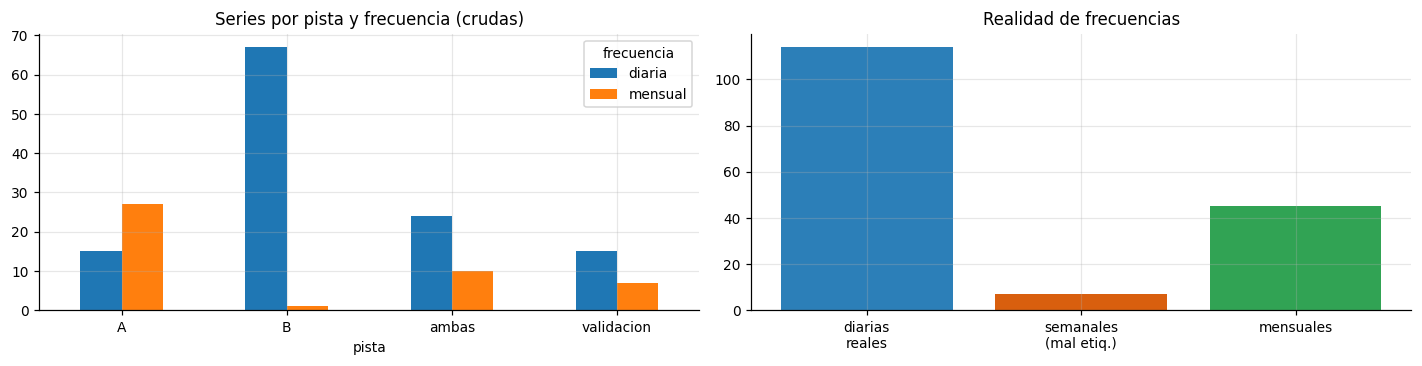

Semanales detectadas (ffill causal, no interpolar): ['ICSA', 'NFCI', 'ANFCI', 'NFCI_RISK', 'NFCI_CREDIT', 'NFCI_LEVERAGE', 'STLFSI4']


In [3]:
frq=ok.copy()
frq['frecuencia']=frq['granularidad']
fig,ax=plt.subplots(1,2,figsize=(13,3.4))
frq.groupby(['pista','frecuencia']).size().unstack(fill_value=0).plot.bar(ax=ax[0])
ax[0].set_title('Series por pista y frecuencia (crudas)'); ax[0].tick_params(axis='x',rotation=0)
# semanales mal etiquetadas 'diaria' (espaciado modal ~7d)
sem=[]
for n in ok[ok.granularidad=='diaria'].nombre:
    s=tryload(n)
    if s is not None and len(s)>50 and s.index.to_series().diff().dt.days.mode().iloc[0]>=5: sem.append(n)
ax[1].bar(['diarias\nreales','semanales\n(mal etiq.)','mensuales'],
          [ (ok.granularidad=='diaria').sum()-len(sem), len(sem), (ok.granularidad=='mensual').sum()],
          color=['#2c7fb8','#d95f0e','#31a354'])
ax[1].set_title('Realidad de frecuencias'); plt.tight_layout(); plt.show()
print('Semanales detectadas (ffill causal, no interpolar):', sem)

### 3.1 Cómo tratamos las no-diarias (la decisión fina)

| Frecuencia | Ejemplos | Tratamiento causal | Por qué |
|---|---|---|---|
| **Semanal** | NFCI, STLFSI4, ICSA | `ffill` al último valor publicado; **sin interpolar** | el dato existe solo desde su release; interpolar inventaría futuro |
| **Mensual macro** | INDPRO, UNRATE, PPI | **lag de publicación** (~1 mes) + `ffill` | INDPRO del mes *M* se publica a mediados de *M+1*: usarlo antes es look-ahead |
| **Mensual mercado** | MOODYS_BAA/AAA (crédito profundo) | `ffill` (el nivel de fin de mes ya es observable) | no hay retardo de publicación relevante |

Además, cada panel llevará una columna **`_edad_dias`** (antigüedad del último dato real) para que el
detector sepa cuándo está "arrastrando" un valor viejo. Lo demostramos con INDPRO:

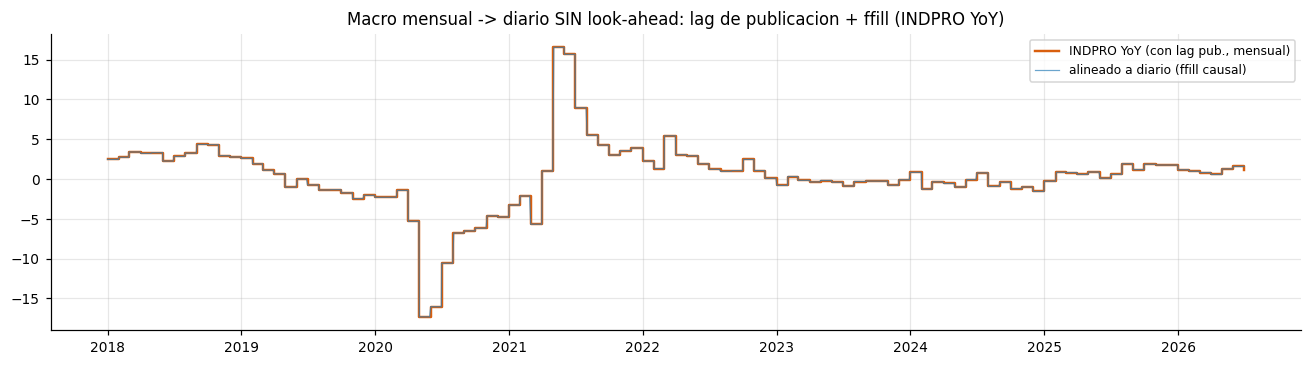

El valor de un mes NO aparece hasta ~1 mes despues (fecha de publicacion). Sin interpolar.


In [4]:
ip=tryload('INDPRO')
if ip is not None:
    yoy=100*ip/ip.shift(12)-100                          # var interanual (mensual)
    LAG=pd.DateOffset(months=1)                          # lag de publicacion conservador
    pub=yoy.copy(); pub.index=pub.index+LAG              # el dato solo existe desde su release
    grid=pd.bdate_range(pub.index.min(), '2026-06-30')   # rejilla diaria
    daily=pub.reindex(grid, method='ffill')              # ffill causal
    fig,ax=plt.subplots(figsize=(12,3.4))
    ax.step(pub.loc['2018':].index, pub.loc['2018':].values, where='post', color='#d95f0e', lw=1.6, label='INDPRO YoY (con lag pub., mensual)')
    ax.plot(daily.loc['2018':].index, daily.loc['2018':].values, color='#2c7fb8', lw=.8, alpha=.7, label='alineado a diario (ffill causal)')
    ax.set_title('Macro mensual -> diario SIN look-ahead: lag de publicacion + ffill (INDPRO YoY)')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()
    print('El valor de un mes NO aparece hasta ~1 mes despues (fecha de publicacion). Sin interpolar.')

## 4. Alineación causal (rejilla NYSE + `reindex`/`ffill`)

El panel diario se construye sobre el **calendario NYSE** (el del S&P 500). Las series FRED (festivos
distintos) se alinean con `reindex`+`ffill` (equivalente a un `merge_asof` **backward**: para cada fecha
NYSE toma el último dato ≤ *t*): nunca mira al futuro. Demostración de que no hay look-ahead:

Fechas NYSE 2015 alineadas: 252 / 252
no-look-ahead en 2015-06-15: con-futuro=2.36  vs  truncado=2.36  ->  CAUSAL OK
Festivos NYSE que FRED no tiene -> arrastra el ultimo valor (<= t), no interpola.


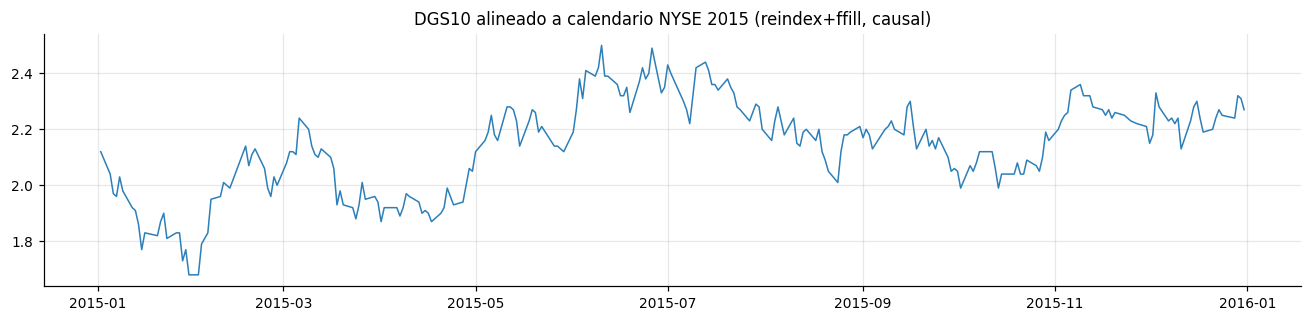

In [5]:
spx=load('SP500'); dgs=load('DGS10')
nyse=spx.loc['2015-01-01':'2015-12-31'].index                 # calendario NYSE 2015
# alinear DGS10 (calendario FRED, festivos distintos) al calendario NYSE, CAUSAL:
# reindex + ffill = para cada fecha NYSE toma el ultimo dato DGS10 <= esa fecha (nunca futuro)
al=dgs.sort_index().reindex(nyse, method='ffill')
# test no-look-ahead: truncar el futuro NO cambia el valor alineado en t
t=pd.Timestamp('2015-06-15')
v_full = dgs.reindex([t], method='ffill').iloc[0]
v_trunc= dgs.loc[:t].reindex([t], method='ffill').iloc[0]
ok_causal = np.isclose(v_full, v_trunc)
print('Fechas NYSE 2015 alineadas:', int(al.notna().sum()), '/', len(al))
print(f'no-look-ahead en {t.date()}: con-futuro={v_full:.2f}  vs  truncado={v_trunc:.2f}  ->  {"CAUSAL OK" if ok_causal else "FUGA!"}')
print('Festivos NYSE que FRED no tiene -> arrastra el ultimo valor (<= t), no interpola.')
fig,ax=plt.subplots(figsize=(12,3)); ax.plot(al.index, al.values, lw=1, color='#2c7fb8')
ax.set_title('DGS10 alineado a calendario NYSE 2015 (reindex+ffill, causal)'); plt.tight_layout(); plt.show()

## 5. Transformaciones causales y verificación de no look-ahead

Recetario (primitivas ya en `src/features.py`): `causal_zscore` (expanding, `min_periods`), `log_returns`,
`realized_vol`, `drawdown`, `momentum`, `rolling_correlation`. **Verificamos** que una feature es causal:
truncar en una fecha y recomputar debe dar exactamente lo mismo (`max_abs_diff = 0`).

VIX_level_z causal: max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK


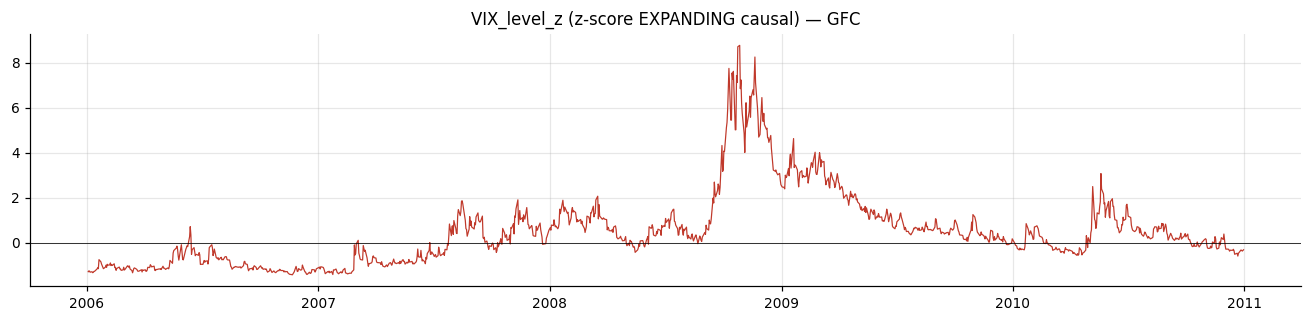

In [6]:
vix=load('VIX').rename('VIX')
full=ft.causal_zscore(vix)
cut='2015-01-01'
trunc=ft.causal_zscore(vix.loc[:cut])
idx=trunc.index.intersection(full.index); idx=idx[idx<=pd.Timestamp(cut)]
mad=float((full.loc[idx]-trunc.loc[idx]).abs().max())
print(f'VIX_level_z causal: max|full - truncado en {cut}| = {mad:.2e}  ->  {"CAUSAL OK" if mad<1e-9 else "LOOK-AHEAD!"}')
fig,ax=plt.subplots(figsize=(12,3)); ax.plot(full.loc['2006':'2010'].index, full.loc['2006':'2010'].values, lw=.8, color='#c0392b')
ax.set_title('VIX_level_z (z-score EXPANDING causal) — GFC'); ax.axhline(0,c='k',lw=.5); plt.tight_layout(); plt.show()

## 6. Deuda de nombres resuelta: catálogo v2 → features

`src/features.py` (heredado de la Capa 1) usaba nombres viejos (`HYG`, `TLT`, `IEF`, `GOLD`). El
preprocesado v2 será **dirigido por catálogo**: mapea los nombres v2 a su rol de feature.

In [7]:
MAP=[('HYG_CREDIT','HYG (credito HY)  -> credit_HYG_IEF, HYG_ret_z'),
     ('IEF_TREASURY','IEF (treasury 7-10y) -> base de credit_HYG_IEF'),
     ('TLT_TREASURY','TLT (treasury 20y+)  -> corr_spx_bond'),
     ('GOLD_GLD','GLD (oro)            -> GOLD_ret_z (refugio)'),
     ('MOODYS_BAA_AAA_SPREAD','spread Baa-Aaa ya calculado -> credit_BaaAaa_z'),
     ('SPDR_XL*','9 sectores           -> sector_dispersion, cyc_def_ratio')]
print('Mapeo nombres catalogo v2 -> feature:')
for a,b in MAP: print(f'  {a:24} {b}')

Mapeo nombres catalogo v2 -> feature:
  HYG_CREDIT               HYG (credito HY)  -> credit_HYG_IEF, HYG_ret_z
  IEF_TREASURY             IEF (treasury 7-10y) -> base de credit_HYG_IEF
  TLT_TREASURY             TLT (treasury 20y+)  -> corr_spx_bond
  GOLD_GLD                 GLD (oro)            -> GOLD_ret_z (refugio)
  MOODYS_BAA_AAA_SPREAD    spread Baa-Aaa ya calculado -> credit_BaaAaa_z
  SPDR_XL*                 9 sectores           -> sector_dispersion, cyc_def_ratio


## 7. Con qué NOS QUEDAMOS y qué se descarta

- **Features** = las de §2 (núcleo + extendido). Es *lo que entra al detector*.
- **Solo-raw**: las series `enricher/fallback` no seleccionadas quedan disponibles en `data/raw/` pero
  **no** se convierten en feature (evitan ruido/redundancia).
- **Solo-validación**: `OFR_FSI`, `NFCI`, `NBER_RECESSION_DAILY`… son **etiquetas/validación laxa**,
  **nunca** features (serían fuga: incorporan información de "ya sabemos que es crisis"). Ver la regla
  anti-fuga en [`docs/GLOSARIO.md`](../docs/GLOSARIO.md).

Series -> FEATURE (fuente de alguna feature): ~35
Series -> SOLO VALIDACION/label (nunca feature): 20
Series -> solo-raw (disponibles, no usadas de momento): ~111


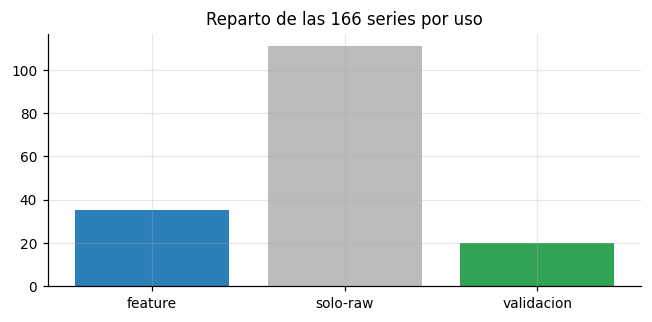

In [8]:
# resolver serie_fuente con comodin (SPDR_XL* -> los 9 sectores) via prefijo
exact=set(); prefixes=set()
for _,r in FEAT.iterrows():
    for s in r['serie_fuente'].split(','):
        s=s.strip()
        (prefixes.add(s[:-1]) if s.endswith('*') else exact.add(s))
def is_feat(n): return (n in exact) or any(n.startswith(p) for p in prefixes)
usa=ok[ok.nombre.apply(is_feat)]
val=ok[ok.rol=='validation']
resto=ok[~ok.nombre.apply(is_feat) & (ok.rol!='validation')]
print(f'Series -> FEATURE (fuente de alguna feature): ~{len(usa)}')
print(f'Series -> SOLO VALIDACION/label (nunca feature): {len(val)}')
print(f'Series -> solo-raw (disponibles, no usadas de momento): ~{len(resto)}')
fig,ax=plt.subplots(figsize=(6,3))
ax.bar(['feature','solo-raw','validacion'],[len(usa),len(resto),len(val)],color=['#2c7fb8','#bbbbbb','#31a354'])
ax.set_title('Reparto de las 166 series por uso'); plt.tight_layout(); plt.show()

## 8. Qué producirá `03_preprocesado` (estructura de salida)

Paneles separados por pista y frecuencia, todos causales y sin imputar, en `data/processed/`:

```
data/processed/
├── pistaA_diaria.parquet      # SP500_ret_z, SP500_vol_z, momentum, drawdown, FF_*  (1927+)
├── pistaA_mensual.parquet     # credit_BaaAaa_z, INDPRO_yoy_z, PPI_yoy_z, UNRATE  (con lag pub.)
├── pistaB_diaria.parquet      # VIX/MOVE/credito/curva/velocidad/sectores/FX  (2003+)
├── pistaB_mensual.parquet     # (si aplica)
├── labels.parquet             # crisis_windows, false_positive_windows, drawdown_troughs (SOLO eval)
└── _meta.json                 # ventana por pista, columnas _edad_dias, checksums, assert_causal=0
```

Cada panel diario llevará su `<feat>_edad_dias` para las columnas arrastradas de baja frecuencia. Los
detectores de la Fase D consumen `pistaX_*` como features y `labels` **solo** para evaluar.

## 9. Decisiones tomadas (checklist)

| # | Decisión | Elección |
|---|---|---|
| 1 | Alcance de features | **Máximo**: núcleo (benchmark) + extendido |
| 2 | Frecuencias | **Paneles separados** diario / mensual, por pista |
| 3 | No-diarias | semanal→ffill; macro mensual→**lag de publicación**+ffill; + columna `_edad_dias` |
| 4 | Alineación | rejilla **NYSE** + `reindex`/`ffill` (≡ merge_asof backward, causal) |
| 5 | Transformaciones | z-score **expanding** (primitivas `src/features.py`); niveles acotados crudos |
| 6 | Nombres | builder **dirigido por catálogo** (mapea nombres v2) |
| 7 | Uso de series | feature / solo-raw / **validación (nunca feature)** |
| 8 | Salida | `data/processed/pista{A,B}_{diaria,mensual}.parquet` + `labels.parquet` + `_meta.json` |
| 9 | Verificación | `assert_causal` (max\|Δ\|=0), cobertura, no-look-ahead antes de cerrar |

> **Siguiente**: con esto aprobado, `03_preprocesado.ipynb` solo implementa la tabla de arriba.